## Intermediate Machine Learning: Assignment 2

**Deadline**

Assignment 2 is due Thursday, October  9 by 11:59 pm. Late work will not be accepted as per the course policies (see the syllabus on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or Copilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a .pdf on Gradescope. To convert your notebook to a .pdf while preserving the cell structure without truncating the output, you can convert to .html using [this notebook](https://colab.research.google.com/github/YData123/sds365-fa25/blob/main/assignments/Convert_ipynb_to_HTML_in_Colab.ipynb). Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

**Topics**

 * Convolutional neural nets
 * Gaussian processes
 * Double descent

Please note that while the problems may look long, we give you substantial starter code to make the work manageable. The course staff members are available to help during office hours!

## Problem 1: Dilation elation (35 points)

### Overview

A dilated convolution (also known as atrous convolution) inserts gaps between kernel entries, so that a $k \times k$ filter “jumps” by a dilation rate $𝑑$. A dilation rate of $d=1$ is the regular convolution. CNN dilation can be adjusted using parameter $d$ as shown in the figure below.  



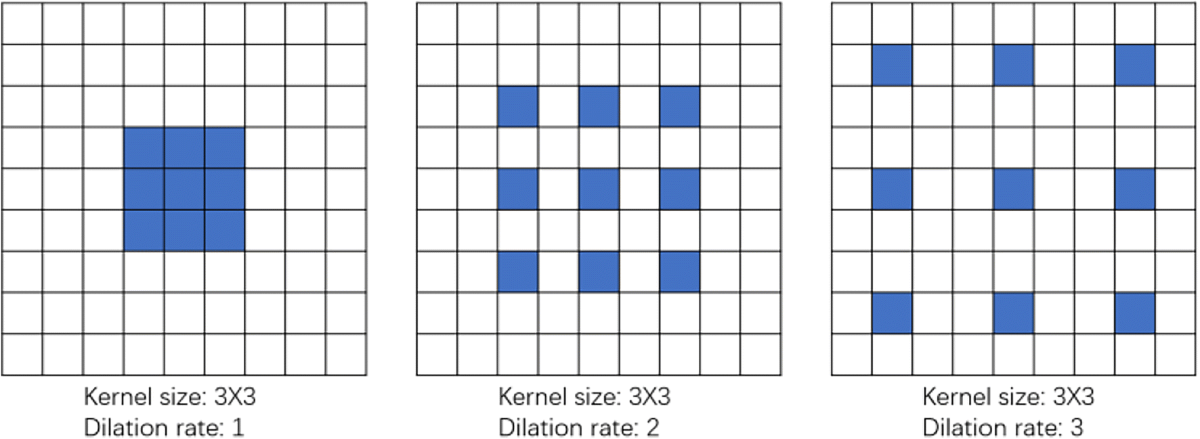




Dilated convolution captures a wider area of the input, allowing for potentially better context modeling without increased computational cost. It expands the effective "receptive field" (the area of the filter) without the need for larger kernels or more model parameters; dilated convolution can also reduce blurring. One of the most successful uses of  dilated convolution was in the first AlphaFold paper, one of the earliest CNN-based attempts to predict the structure of proteins. For a glimpse of the full architecture and its details you may wish to take a look at https://www.nature.com/articles/s41586-019-1923-7

In this problem, we use dilated convolution to analyze MRI images to detect the presence of certain types of brain tumors. Cues about tumor type can include texture information (enhanced rim, necrotic core) and global characteristics (edema extent, mass effect, midline shift). Dilation expands the effective receptive field while keeping high-resolution features available for downstream neural network layers that make the multi-class decision. This approach is also helps address the problem of "anisotropy" where some characteristics are directionally dependent, by trying to incorporate a larger sub image in the kernel.

In the first part of this problem, we implement a regular CNN. Then, your job will be to implement a dilated CNN, and to choose the dilation parameters so that the model is as accurate as you can make it.  Finally, we use Monte Carlo dropout as a way to estimate the uncertainty in the predictions.

### Dilated convolution in one and two dimensions

**Symbols (what each letter means):**
- $x$: the **input** (a 1D signal for the first formula; a 2D image for the second).
- $y$: the **output feature map** after convolution (same shape type as $x$).
- $w \in \mathbb{R}^{k}$: a 1D **kernel/filter** of length $k$.
- $W \in \mathbb{R}^{k\times k}$: a 2D **kernel/filter** of size $k \times k$.
- $k$: **kernel size** (e.g., $k=3$ for a $3\times3$ kernel).
- $d$: **dilation rate** (how far apart the kernel taps are; $d=1$ is a standard convolution).
- $i,j$: spatial **indices** of the output $y$ (row/column).
- $m,u,v$: **indices inside the kernel** (1D: $m$, 2D: $u$ for rows, $v$ for cols).
- $u_c=\lfloor k/2\rfloor$, $v_c=\lfloor k/2\rfloor$: the **kernel center** offsets (so the kernel is centered).
- We assume **stride $=1$** and appropriate padding so indices are valid.


---
---


**1D dilated convolution** of a signal $x$ with kernel $w \in \mathbb{R}^{k}$ and dilation $d \in \mathbb{N}$:
$$
y[i] \;=\; \sum_{m=0}^{k-1} w[m]\; x\!\bigl(i + d\,m\bigr).
$$

**2D dilated convolution** of an image $x$ with kernel $W \in \mathbb{R}^{k\times k}$ and dilation $d$ (stride $1$).  
Let $u_c=\lfloor k/2\rfloor$ and $v_c=\lfloor k/2\rfloor$ denote the kernel center:
$$
y[i,j] \;=\; \sum_{u=0}^{k-1}\sum_{v=0}^{k-1}
W[u,v]\; x\!\bigl(i + d\,(u-u_c),\; j + d\,(v-v_c)\bigr).
$$

**Effective receptive field** of a $k\times k$ kernel with dilation $d$:
$$
k_{\text{eff}} \;=\; k + (k-1)\,(d-1).
$$

For example, for $k=3$ and $d=3$, we get $k_{\text{eff}}=7$.  
(When $d=1$, this reduces to the standard convolution.)

### Loading the MRI data

The data used in this problem is cropped from this Kaggle repository https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset.

We only use the data corresponding to glioma tumors and non-tumor images. You can access the data in a zip file at [https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/](https://github.com/YData123/sds365-fa25/tree/main/assignments/assn2/).
You will need to upload the data to your Google Drive.

The cell below gives Colab access to your Google Drive.


In [19]:
# Please do not edit this cell.
# Imports
import os, random, time, math, keras, json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import layers as L, models as M

# (Colab) Mount Google Drive
from google.colab import drive
if not os.path.ismount("/content/drive"):
  drive.mount("/content/drive")

Now that we mounted Google Drive let's try visualizing images in the training data for the tumor and non-tumor classes.

In [5]:
# Do not edit this block.
# Point to the MRI/ folder that contains Training/ and Testing/
ROOT = "/content/drive/MyDrive/MRI"

TRAIN_DIR = os.path.join(ROOT, "Training")
TEST_DIR  = os.path.join(ROOT, "Testing")
CLASS_NAMES = ["glioma", "notumor"]  # expected two folders inside both training/ and testing/

# Validation of directory structure
def assert_dir(p):
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Expected directory not found: {p}")

assert_dir(ROOT)
assert_dir(TRAIN_DIR)
assert_dir(TEST_DIR)

# Load image as grayscale for consistent viewing
def load_img_gray(path):
    img = Image.open(path).convert("L")  # force grayscale
    return img

# List image files in a folder
def count_images(folder):
    exts = ("*.jpg", "*.jpeg")
    files = []
    for e in exts:
        files.extend(glob(os.path.join(folder, e)))
    return sorted(files)

The data we have requires pre-processing in order to be fed to any neural networks. The inconsistencies in the size as you see in the above output becomes problematic during feeding the data to the network. In this block, we strive to solve that issue.

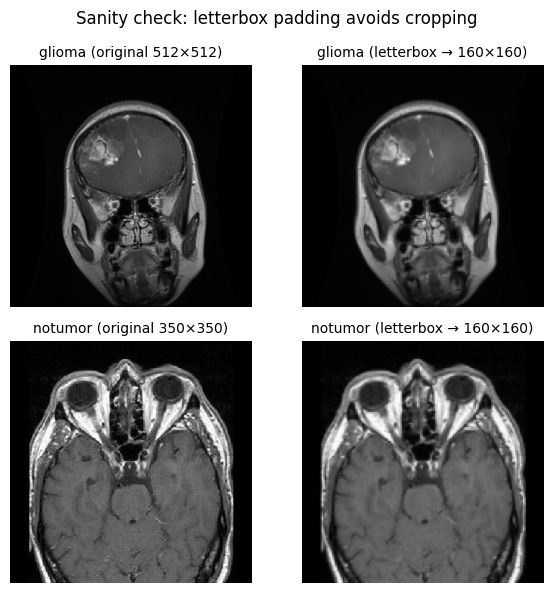

In [6]:
# Helper functions: letterbox pad to square (no cropping) + resize to 160x160

IMG_SIZE = 160  # target size used throughout the assignment

def letterbox_to_square(img: Image.Image, fill=0) -> Image.Image:
    """
    Pads the image to a square using 'fill' (black), centered, without distortion.
    Keeps original content intact (no cropping).
    """
    if img.mode not in ("L", "RGB"):
        img = img.convert("L")
    w, h = img.size
    s = max(w, h)
    canvas = Image.new(img.mode, (s, s), color=fill)
    canvas.paste(img, ((s - w)//2, (s - h)//2))
    return canvas

def preprocess_image(img: Image.Image, size: int = IMG_SIZE) -> Image.Image:
    """Letterbox pad -> resize to (size, size)."""
    sq = letterbox_to_square(img, fill=0)
    return sq.resize((size, size), resample=Image.BILINEAR)

# Visualize ORIGINAL vs PREPROCESSED (letterboxed) for first training image of each class
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(6, 3*len(CLASS_NAMES)))
if len(CLASS_NAMES) == 1:
    axes = np.array([axes])  # ensure 2D array indexing

for i, c in enumerate(CLASS_NAMES):
    class_dir = os.path.join(TRAIN_DIR, c)
    files = count_images(class_dir)
    ax_orig, ax_proc = axes[i, 0], axes[i, 1]
    if not files:
        ax_orig.axis("off"); ax_proc.axis("off")
        ax_proc.set_title(f"No images found for {c}")
        continue

    p = files[0]
    img = load_img_gray(p)            # original grayscale
    proc = preprocess_image(img)      # padded + resized 160x160

    ax_orig.imshow(img, cmap="gray");  ax_orig.axis("off")
    ax_orig.set_title(f"{c} (original {img.size[0]}×{img.size[1]})", fontsize=10)

    ax_proc.imshow(proc, cmap="gray"); ax_proc.axis("off")
    ax_proc.set_title(f"{c} (letterbox → {IMG_SIZE}×{IMG_SIZE})", fontsize=10)

plt.suptitle("Sanity check: letterbox padding avoids cropping", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Gather file paths & labels; split TRAIN into train/validation (TEST untouched)

def list_images_with_labels(root_dir, classes):
    paths, labels = [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(root_dir, cname)
        for p in count_images(cdir):
            paths.append(p); labels.append(ci)
    return np.array(paths), np.array(labels)

# load TRAIN and TEST file lists
train_paths, train_labels = list_images_with_labels(TRAIN_DIR, CLASS_NAMES)
test_paths,  test_labels  = list_images_with_labels(TEST_DIR,  CLASS_NAMES)

# stratified split of TRAIN -> (train, val)
VAL_FRACTION = 0.20
tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=VAL_FRACTION,
    random_state=42,
    stratify=train_labels
)

print(f"Counts -> train: {len(tr_paths)}, val: {len(val_paths)}, test: {len(test_paths)}")

Counts -> train: 2332, val: 584, test: 705


In [10]:
# TensorFlow input pipeline with the SAME preprocessing:
# grayscale -> letterbox to square (no crop) -> resize to IMG_SIZE -> per-image z-score

def tf_letterbox_resize(img, target=IMG_SIZE):
    shape = tf.shape(img)
    h, w = shape[0], shape[1]
    s = tf.maximum(h, w)
    pad_top  = (s - h) // 2
    pad_bottom = s - h - pad_top
    pad_left = (s - w) // 2
    pad_right = s - w - pad_left
    img_sq = tf.pad(img, [[pad_top, pad_bottom],[pad_left, pad_right],[0,0]], mode="CONSTANT", constant_values=0.0)
    img_rs = tf.image.resize(img_sq, (target, target), method="bilinear")
    return img_rs

def tf_per_image_zscore(img):
    mean = tf.reduce_mean(img)
    std  = tf.math.reduce_std(img)
    return (img - mean) / tf.maximum(std, 1e-6)

def load_and_preprocess(path, label, augment=False):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf_letterbox_resize(img, target=IMG_SIZE)

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.10)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)

    img = tf_per_image_zscore(img)
    label = tf.cast(label, tf.float32)
    label = tf.expand_dims(label, axis=-1)   # (1,)
    return img, label

def make_dataset(paths, labels, batch_size=32, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_and_preprocess(p, y, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 16
ds_train = make_dataset(tr_paths,  tr_labels,  batch_size=BATCH_SIZE, shuffle=True,  augment=True)
ds_val   = make_dataset(val_paths, val_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)
ds_test  = make_dataset(test_paths, test_labels, batch_size=BATCH_SIZE, shuffle=False, augment=False)

for xb, yb in ds_train.take(1):
    print("Train batch:", xb.shape, yb.shape)

Train batch: (16, 160, 160, 1) (16, 1)


/tmp/ipython-input-1886849759.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c = int(yb[i])


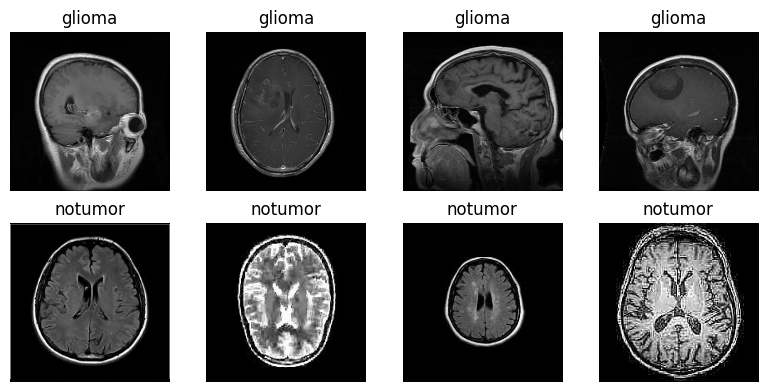

In [11]:
# Quick visual sanity check: Show 4 preprocessed samples per class from the TRAIN pipeline
class_names = CLASS_NAMES

# collect a small batch
xb, yb = next(iter(ds_train))
xb = xb.numpy(); yb = yb.numpy()

fig, axes = plt.subplots(2, 4, figsize=(8,4))
axes = axes.reshape(-1)
shown = {i:0 for i in range(len(class_names))}
for i in range(len(xb)):
    c = int(yb[i])
    if shown[c] >= 4:
        continue
    axes[c*4 + shown[c]].imshow(xb[i,...,0], cmap="gray")
    axes[c*4 + shown[c]].axis("off")
    axes[c*4 + shown[c]].set_title(class_names[c])
    shown[c]+=1
    if all(v==4 for v in shown.values()):
        break
plt.tight_layout(); plt.show()

In [8]:
"""
You'll learn two new layers in this assignment. MCSpatialDropout2D is a smarter type of dropout for image processing
networks. Instead of randomly turning off individual pixels, it turns off entire channels (feature detectors) all at
once. This works better for images because it prevents the network from getting too dependent on specific feature
detectors working together, which helps it generalize better to new data. BatchNormalization helps keep your network's
internal signals stable during training. It takes the outputs from each layer and normalizes them (resembling standardizing
data), then applies two learnable parameters to scale and shift the results as needed. This makes training more stable and
often lets you use higher learning rates, leading to faster and more reliable training.
"""
# Keras model factory: Build a baseline CNN
# Force-dropout layers that stay active at inference for MC sampling (BatchNorm stays frozen)
@keras.saving.register_keras_serializable(package="mc")
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

@keras.saving.register_keras_serializable(package="mc")
class MCSpatialDropout2D(tf.keras.layers.SpatialDropout2D):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

def build_cnn(
    dilated=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=1,                # 1 sigmoid unit (binary)
    drop_rate=0.20,
    use_mc_dropout=True,          # if True, use MC* layers; else standard Dropout
    use_spatial=True              # SpatialDropout2D is usually better for convs
):
    """
    Tiny CNN; toggle dilation in block-2 convs. Adds dropout so MC sampling works.
    - dilated=False: Conv3x3 (rate=1)
    - dilated=True : dilation rates (2,3,5) in the 2nd conv of each block
    - Dropout: after each block; optionally before Dense head
    """
    rates = (1,1,1)

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)  # a small dense-level dropout is fine (standard)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)  # binary head
    model = tf.keras.Model(x_in, out)
    return model

# Rebuild models (students then train as in Step 14)
model_base = build_cnn(dilated=False)
model_base.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d            │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_1          │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_2          │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

### Problem 1.1: Explain the CNN

The cell above shows layer of the CNN, with the output tensor shape and the number of trainable parameters. For each layer, explain in a couple of sentences (1) what the purpose of the layer is (2) why the output shape and number of parameters are as shown.

[your markdown here]


- **InputLayer**
  - **Purpose:** declares input shape.
  - **Why shape/params:** images are grayscale $160\times160\times1$, batch dimension is `None`; no weights → **0 params**.

- **Conv2D (32 filters)**
  - **Purpose:** extract local features with $3\times3$ kernels.
  - **Why:** same padding keeps $160\times160$; 32 channels out. Params $(3\cdot3\cdot1+1)\cdot32=320$.

- **BatchNormalization (32 ch.)**
  - **Purpose:** stabilize training; learn per-channel scale/shift.
  - **Why:** shape unchanged; trainable $\gamma,\beta$ plus non-trainable running stats → **$4\cdot32=128$ params**.

- **Conv2D_1 (32 filters)**
  - **Purpose:** deeper features at same resolution.
  - **Why:** $(3\cdot3\cdot32+1)\cdot32=9{,}248$; shape $(160,160,32)$.

- **BatchNormalization_1 (32 ch.)**
  - **Purpose/Why:** as above; **128 params**; shape unchanged.

- **MaxPooling2D (2×2, s=2)**
  - **Purpose:** downsample spatial size; keep strongest activations.
  - **Why:** halves $H,W$ → $(80,80,32)$; **0 params**.

- **MCSpatialDropout2D**
  - **Purpose:** regularization by dropping entire feature maps (MC inference).
  - **Why:** no weights; shape unchanged $(80,80,32)$.

- **Conv2D_2 (64 filters)**
  - **Purpose:** increase channel capacity.
  - **Why:** $(3\cdot3\cdot32+1)\cdot64=18{,}496$; shape $(80,80,64)$.

- **BatchNormalization_2 (64 ch.)**
  - **Purpose/Why:** BN; **256 params**; shape unchanged.

- **Conv2D_3 (64 filters)**
  - **Purpose:** refine 64-channel features.
  - **Why:** $(3\cdot3\cdot64+1)\cdot64=36{,}928$; shape $(80,80,64)$.

- **BatchNormalization_3 (64 ch.)**
  - **Purpose/Why:** BN; **256 params**; same shape.

- **MaxPooling2D_1 (2×2, s=2)**
  - **Purpose:** further downsample.
  - **Why:** $(40,40,64)$; **0 params**.

- **MCSpatialDropout2D_1**
  - **Purpose/Why:** regularization; **0 params**; shape unchanged.

- **Conv2D_4 (128 filters)**
  - **Purpose:** expand feature depth.
  - **Why:** $(3\cdot3\cdot64+1)\cdot128=73{,}856$; shape $(40,40,128)$.

- **BatchNormalization_4 (128 ch.)**
  - **Purpose/Why:** BN; **512 params**; same shape.

- **Conv2D_5 (128 filters)**
  - **Purpose:** richer features at same resolution.
  - **Why:** $(3\cdot3\cdot128+1)\cdot128=147{,}584$; shape $(40,40,128)$.

- **BatchNormalization_5 (128 ch.)**
  - **Purpose/Why:** BN; **512 params**; same shape.

- **MCSpatialDropout2D_2**
  - **Purpose/Why:** regularization; **0 params**; $(40,40,128)$.

- **GlobalAveragePooling2D**
  - **Purpose:** convert each channel map to a single number by spatial averaging; reduces overfitting vs. large Dense.
  - **Why:** $(40,40,128)\rightarrow(128)$; **0 params**.

- **Dropout**
  - **Purpose:** regularization by randomly zeroing activations.
  - **Why:** shape stays $(128)$; **0 params**.

- **Dense (1 unit)**
  - **Purpose:** final linear layer for binary output (often with sigmoid).
  - **Why:** weights $128\cdot1$ plus bias $1$ → **129 params**; shape $(1)$.




The following cell now trains the baseline CNN, and evaluates it on test data.

In [10]:
# Train the baseline model (with validation) + evaluate on TEST + plots

EPOCHS  = 10
OUTDIR  = "/content/outputs_cnn_dilation"
os.makedirs(OUTDIR, exist_ok=True)

def compile_model(m):
    m.compile(optimizer=tf.keras.optimizers.Adam(3e-5),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5)])
    return m

def train_model(model, name, train_ds, val_ds, epochs=EPOCHS):
    ckpt = os.path.join(OUTDIR, f"{name}.keras")  # best checkpoint
    cbs = [ModelCheckpoint(ckpt, monitor="val_accuracy", save_best_only=True, verbose=1)]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=cbs, verbose=1)
    train_seconds = time.time() - t0
    print(f"[TIMER] {name}: training wall-clock = {train_seconds:.2f} sec "
          f"({train_seconds/max(1,len(hist.history['loss'])):.2f} sec/epoch) (monitoring val_accuracy)")
    # OPTIONAL: save the final weights separately (do NOT overwrite ckpt)
    final_path = os.path.join(OUTDIR, f"{name}_final.keras")
    model.save(final_path)
    return ckpt, hist, train_seconds

def evaluate_and_report(model, ds, class_names):
    y_true, y_pred = [], []
    out_last_dim = model.output_shape[-1]  # 1 for sigmoid, 2 for softmax
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        probs = np.array(probs).reshape((probs.shape[0], -1))
        preds = (probs[:,0] >= 0.5).astype(int) if out_last_dim == 1 else np.argmax(probs, axis=1)
        yt = yb.numpy().reshape(-1).astype(int)
        y_true.append(yt); y_pred.append(preds)
    y_true = np.concatenate(y_true); y_pred = np.concatenate(y_pred)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    return y_true, y_pred

def measure_eval_time(model, ds, n_samples):
    t0 = time.time()
    loss, acc = model.evaluate(ds, verbose=0)
    eval_seconds = time.time() - t0
    print(f"[TIMER] evaluate: {eval_seconds:.2f} sec")
    t1 = time.time()
    _ = model.predict(ds, verbose=0)
    pred_seconds = time.time() - t1
    ips = n_samples / pred_seconds if pred_seconds > 0 else float("inf")
    print(f"[TIMER] predict : {pred_seconds:.2f} sec  (~{ips:.1f} images/sec)")
    return loss, acc, eval_seconds, pred_seconds, ips

# --- compile
model_base = compile_model(model_base)

# --- train with validation (no test leakage)
ckpt_base, hist_base, train_time_base = train_model(model_base, "baseline_cnn", ds_train, ds_val, epochs=EPOCHS)

# --- reload best and evaluate on TEST (timed)
model_base = tf.keras.models.load_model(ckpt_base)

print("\n[TEST] Baseline:")
y_true_base, y_pred_base = evaluate_and_report(model_base, ds_test, CLASS_NAMES)
loss_b, acc_b, eval_t_b, pred_t_b, ips_b = measure_eval_time(model_base, ds_test, n_samples=len(test_paths))

print(f"\n[TEST] Baseline -> loss: {loss_b:.4f} | acc: {acc_b:.4f}")



Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5737 - loss: 0.6673
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.5742 - loss: 0.6670 - val_accuracy: 0.4538 - val_loss: 1.0882
Epoch 2/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7230 - loss: 0.5539
Epoch 2: val_accuracy improved from 0.45377 to 0.45719, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.7231 - loss: 0.5538 - val_accuracy: 0.4572 - val_loss: 1.0300
Epoch 3/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7639 - loss: 0.5075
Epoch 3: val_accuracy improved from 0.45719 to 0.62329, saving model to /content/outputs_cnn_dilation/baseline_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.7641 - loss: 0.5072 - val_accuracy: 0.6233 - val_loss: 0.6635
Epoch 4/10
146/146 ━━━━━━━

### Problem 1.2: Improve on the baseline with a dilated CNN

Your job is now to use the above code, appropriately modified as needed, to build and train a dilated CNN that has better accuracy than the baseline.

Note that the keras Conv2D method can handle dilation. You may experiment with any architecture (combination of layers) and dilation parameters that you wish.

To keep the notebook clear, only show your best model, not intermediate, experimental models. Explain your choice of model, and why your best dilation CNN model does or does not improve on the baseline. Note that you should use a runtime environment that uses a GPU for faster processing speed.

In [12]:
# Keras model factory: Build a baseline CNN
# Force-dropout layers that stay active at inference for MC sampling (BatchNorm stays frozen)
@keras.saving.register_keras_serializable(package="mc")
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

@keras.saving.register_keras_serializable(package="mc")
class MCSpatialDropout2D(tf.keras.layers.SpatialDropout2D):
    def call(self, inputs, training=None):
        # Force sampling masks even at inference for MC passes
        return super().call(inputs, training=True)

def build_cnn(
    dilated=False,
    dilation_rates=(1, 1, 1), # Added dilation_rates parameter
    input_shape=(IMG_SIZE, IMG_SIZE, 1),
    num_classes=1,                # 1 sigmoid unit (binary)
    drop_rate=0.20,
    use_mc_dropout=True,          # if True, use MC* layers; else standard Dropout
    use_spatial=True              # SpatialDropout2D is usually better for convs
):
    """
    Tiny CNN; toggle dilation in block-2 convs. Adds dropout so MC sampling works.
    - dilated=False: Conv3x3 (rate=1)
    - dilated=True : dilation rates (2,3,5) in the 2nd conv of each block
    - Dropout: after each block; optionally before Dense head
    """
    rates = dilation_rates if dilated else (1, 1, 1) # Use provided dilation_rates if dilated is True

    Drop = (MCSpatialDropout2D if (use_mc_dropout and use_spatial) else
            L.SpatialDropout2D if use_spatial else
            MCDropout if use_mc_dropout else
            L.Dropout)

    x_in = L.Input(shape=input_shape)
    x = x_in

    # Block A
    x = L.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(32, 3, padding="same", activation="relu", dilation_rate=rates[0])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block B
    x = L.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(64, 3, padding="same", activation="relu", dilation_rate=rates[1])(x)
    x = L.BatchNormalization()(x)
    x = L.MaxPool2D(pool_size=2)(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    # Block C
    x = L.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = L.BatchNormalization()(x)
    x = L.Conv2D(128, 3, padding="same", activation="relu", dilation_rate=rates[2])(x)
    x = L.BatchNormalization()(x)
    x = Drop(drop_rate)(x)  # <-- dropout for MC

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = L.Dropout(drop_rate)(x)  # a small dense-level dropout is fine (standard)

    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)  # binary head
    model = tf.keras.Model(x_in, out)
    return model

# Rebuild models (students then train as in Step 14)
model_base = build_cnn(dilated=False)
model_base.summary()

# Build dilated model with example dilation rates
model_dilated = build_cnn(dilated=True, dilation_rates=(2, 3, 5))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_3          │ (None, 80, 80, 32)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_4          │ (None, 40, 40, 64)     │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_spatial_dropout2d_5          │ (None, 40, 40, 128)    │             0 │
│ (MCSpatialDropout2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             

 Total params: 288,353 (1.10 MB)

 Trainable params: 287,457 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [13]:
# --- compile
model_dilated = compile_model(model_dilated)

# --- train with validation (no test leakage)
ckpt_dilated, hist_dilated, train_time_dilated = train_model(model_dilated, "dilated_cnn", ds_train, ds_val, epochs=EPOCHS)

# --- reload best and evaluate on TEST (timed)
model_dilated = tf.keras.models.load_model(ckpt_dilated)

print("\n[TEST] Dilated CNN:")
y_true_dilated, y_pred_dilated = evaluate_and_report(model_dilated, ds_test, CLASS_NAMES)
loss_d, acc_d, eval_t_d, pred_t_d, ips_d = measure_eval_time(model_dilated, ds_test, n_samples=len(test_paths))

print(f"\n[TEST] Dilated CNN -> loss: {loss_d:.4f} | acc: {acc_d:.4f}")

Epoch 1/10
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6051 - loss: 0.6384
Epoch 1: val_accuracy improved from -inf to 0.45377, saving model to /content/outputs_cnn_dilation/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.6055 - loss: 0.6382 - val_accuracy: 0.4538 - val_loss: 1.0721
Epoch 2/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7313 - loss: 0.5339
Epoch 2: val_accuracy improved from 0.45377 to 0.45719, saving model to /content/outputs_cnn_dilation/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.7317 - loss: 0.5336 - val_accuracy: 0.4572 - val_loss: 1.2297
Epoch 3/10
145/146 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7933 - loss: 0.4561
Epoch 3: val_accuracy improved from 0.45719 to 0.56164, saving model to /content/outputs_cnn_dilation/dilated_cnn.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7934 - loss: 0.4559 - val_accuracy: 0.5616 - val_loss: 0.8050
Epoch 4/10
145/146 ━━━━━

### Discussion of Dilated CNN Results
The dilated CNN clearly outperforms the baseline: higher accuracy, lower loss, and better F1—especially by boosting recall on the “notumor” class (fewer missed negatives). I paid a small runtime cost for a significantly better classifier.

### Problem 1.3 Monte Carlo dropout to assess model uncertainty

Your CNN should use Monte Carlo (MC) dropout to compute the risk at test time. For a fixed MRI image scan $x$, you obtain $T$ stochastic predictions $\{\hat y_t\}_{t=1}^T$.

<br>

**(a) Mean and variance from MC passes.**
Give mathematical expressions for the MC estimate of the predictive mean $\mu_T$ and its variance $s_T^2$ from $\{\hat y_t\}$.

<br>

[your markdown or scanned solution here]

The Monte Carlo estimate of the predictive mean $\mu_T$ is the average of these $T$ predictions:

$$ \mu_T = \frac{1}{T} \sum_{t=1}^T \hat y_t $$

The Monte Carlo estimate of the predictive variance $s_T^2$ is the sample variance of these $T$ predictions:

$$ s_T^2 = \frac{1}{T-1} \sum_{t=1}^T (\hat y_t - \mu_T)^2 $$

<br>

**(b) Accuracy guarantee.**
Using Chebyshev’s inequality, derive a lower bound on $T$ ensuring
$\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\big)\le \delta$.
Express the minimal $T$ in terms of $\operatorname{Var}(\hat y_t)$ (or a plug-in estimate).
Clearly state any assumptions you need to make, such as Gaussianity.

<br>

[your markdown or scanned solution here]

\textbf{(b) Accuracy guarantee (via Chebyshev).}

Assume the MC-dropout predictions $\{\hat y_t\}_{t=1}^T$ are i.i.d., with finite variance and mean $\mu_{\text{true}}$, i.e., $\mathbb{E}[\hat y_t]=\mu_{\text{true}}$ and $\operatorname{Var}(\hat y_t)=\sigma^2<\infty$. The sample mean is $\mu_T=\frac{1}{T}\sum_{t=1}^T \hat y_t$, so $\operatorname{Var}(\mu_T)=\sigma^2/T$. Chebyshev’s inequality gives
$$
\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\big)
\le \frac{\operatorname{Var}(\mu_T)}{\varepsilon^2}
= \frac{\sigma^2}{T\,\varepsilon^2}.
$$
To ensure $\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge \varepsilon\big)\le \delta$, it suffices that
$$
T \;\ge\; \frac{\sigma^2}{\delta\,\varepsilon^2}.
$$


If $\sigma^2$ is unknown, use a plug-in estimate from a pilot run of size $T_0$:
$$
T \;\gtrsim\; \frac{s_{T_0}^2}{\delta\,\varepsilon^2},
$$
where $s_{T_0}^2$ is the sample variance of $\{\hat y_t\}_{t=1}^{T_0}$.

Assumptions: .i.d. MC predictions (conditional on the fixed input $x$), finite variance, and unbiasedness of the sample mean.


**(c) Numerical budget.**
With target $\varepsilon=0.05$, confidence $1-\delta=0.95$ ($\delta=0.05$), a pilot of $T_0=50$ passes giving standard deviation $s_{T_0}^2=0.08$, compute the required $T$ from part (b). Describe what this means--what guarantee does this give about the accuracy of the prediction?

[your markdown or scanned solution here]

Using the bound from (b),
$$
T \;\ge\; \frac{\sigma^2}{\delta\,\varepsilon^2}.
$$
Plug in $\varepsilon=0.05$, $\delta=0.05$, and the pilot \emph{variance} estimate $s_{T_0}^2=0.08$:
$$
T \;\ge\; \frac{0.08}{0.05\cdot(0.05)^2}
= \frac{0.08}{0.000125}
= 640.
$$

Interpretation: With $T=640$ MC-dropout passes,
$$
\Pr\!\big(|\mu_T-\mu_{\text{true}}|\ge 0.05\big)\;\le\;0.05,
$$
i.e., with probability at least $95\%$ the Monte Carlo estimate $\mu_T$ is within $\pm 0.05$ of the true predictive mean (under i.i.d. passes with finite variance).


### Problem 1.4 Monte Carlo (MC) Dropout on test images

You will implement MC Dropout to quantify predictive uncertainty at test time. By keeping Dropout active during inference and sampling the model multiple times on the same inputs, you will approximate the posterior predictive distribution and summarize it with a mean prediction and a dispersion measure (standard deviation). Use MC Dropout to approximate the posterior predictive and quantify epistemic uncertainty at test time. Keep dropout on during inference, sample the model multiple times on the same inputs, and summarize the resulting distribution. Set the number of stochastic forward passes to a reasonable value based on the outputs you obtain. Remember by default model.predict does not keep dropout active at inference.

In this part you will:

1.   Build A sampler function that deterministically picks the first 5 images per class from the test set folder for each label (10 images in total)
2.   A stochastic inference predictive route that runs the model with dropout active and returns one probability per image in each round. Your CNN models is preferably defined as a function so that you can feed the baseline and dilated CNNs to compare the values here.
3. Calculate the mean and standard deviation of the stochastic forward passes in step 2 to generate a table or grid that depicts idices, y_true, y_hat,p_mean, p_std. The two latter values should be obtained with your stochastic forward passes with dropout on.
4. See if there is a mispredicted label based on your y_hat, then discuss the correlation between standard deviation of the stochastic runs and the final y_hat.

In [13]:
# 1. Build a sampler function to pick the first 5 images per class from the test set.
def sample_test_images(test_paths, test_labels, class_names, num_per_class=5):
    sampled_paths = []
    sampled_labels = []
    for i, class_name in enumerate(class_names):
        class_paths = [p for p, label in zip(test_paths, test_labels) if label == i]
        sampled_paths.extend(class_paths[:num_per_class])
        sampled_labels.extend([i] * num_per_class)
    return np.array(sampled_paths), np.array(sampled_labels)

# Sample 10 images from the test set (5 per class)
mc_test_paths, mc_test_labels = sample_test_images(test_paths, test_labels, CLASS_NAMES, num_per_class=5)

# Create a dataset for the sampled images
ds_mc_test = make_dataset(mc_test_paths, mc_test_labels, batch_size=len(mc_test_paths), shuffle=False, augment=False)

print(f"Sampled {len(mc_test_paths)} test images for MC dropout.")

Sampled 10 test images for MC dropout.


In [14]:
# 2. Implement a stochastic inference predictive route
def predict_stochastic(model, dataset, num_passes=100):
    """Runs stochastic forward passes with dropout active and returns predictions."""
    all_predictions = []
    for _ in range(num_passes):
        predictions = model.predict(dataset, verbose=0)
        all_predictions.append(predictions)
    return np.array(all_predictions) # Shape: (num_passes, num_samples, 1)

NUM_MC_PASSES = 100
mc_predictions = predict_stochastic(model_dilated, ds_mc_test, num_passes=NUM_MC_PASSES)

# Shape of mc_predictions should be (NUM_MC_PASSES, num_sampled_images, 1)
print(f"Shape of MC predictions: {mc_predictions.shape}")

Shape of MC predictions: (100, 10, 1)


In [25]:
import pandas as pd

# 3. Calculate mean and standard deviation of stochastic forward passes and display results
# The shape of mc_predictions is expected to be (num_passes, num_samples, 1).
# Reshape to (num_passes, num_samples) to work with mean and std calculations.
mc_predictions = mc_predictions.reshape(mc_predictions.shape[0], mc_predictions.shape[1])

p_mean = np.mean(mc_predictions, axis=0)
p_std = np.std(mc_predictions, axis=0)

# Get the ground truth labels for the sampled images
y_true = mc_test_labels

# Calculate the deterministic prediction (using mean of MC predictions >= 0.5)
# This is an estimate of y_hat from a single standard pass, but derived from MC mean
y_hat = (p_mean >= 0.5).astype(int)

# Create a table or grid of results
results = {
    'Image Index': np.arange(len(mc_test_paths)),
    'y_true': y_true,
    'y_hat': y_hat,
    'p_mean': p_mean,
    'p_std': p_std
}

results_df = pd.DataFrame(results)
display(results_df)

# 4. Discuss mispredicted labels and correlation between std dev and y_hat
mispredicted_indices = results_df[results_df['y_true'] != results_df['y_hat']].index.tolist()

print("\nDiscussion:")
if mispredicted_indices:
    print(f"Mispredicted images (indices): {mispredicted_indices}")
    print("For mispredicted images, the 'y_hat' label does not match the 'y_true' label.")
else:
    print("No mispredicted images in the sampled subset.")

print("\nCorrelation between standard deviation (p_std) and prediction (y_hat):")
# Analyze the relationship between p_std and whether the prediction y_hat is confident (close to 0 or 1)
# Higher p_std indicates higher uncertainty. We expect higher uncertainty for mispredicted or less confident predictions.

# Example analysis: Check p_std for mispredicted vs correctly predicted samples
if mispredicted_indices:
    print(f"Average p_std for mispredicted images: {results_df.loc[mispredicted_indices, 'p_std'].mean():.4f}")
correctly_predicted_indices = results_df[results_df['y_true'] == results_df['y_hat']].index.tolist()
if correctly_predicted_indices:
     print(f"Average p_std for correctly predicted images: {results_df.loc[correctly_predicted_indices, 'p_std'].mean():.4f}")

# Another way: Look at p_std values for samples where p_mean is close to 0.5 (less confident)
less_confident_indices = results_df[(results_df['p_mean'] > 0.4) & (results_df['p_mean'] < 0.6)].index.tolist()
if less_confident_indices:
    print(f"\nImages with less confident predictions (p_mean between 0.4 and 0.6): {less_confident_indices}")
    print(f"Average p_std for less confident predictions: {results_df.loc[less_confident_indices, 'p_std'].mean():.4f}")

print("\nGenerally, a higher standard deviation suggests higher uncertainty in the model's prediction for that image. Hence, we see higher standard deviations for mispredicted images.")

,Image Index,y_true,y_hat,p_mean,p_std
0,0,0,1,0.505314,0.007561
1,1,0,1,0.506904,0.007689
2,2,0,1,0.505626,0.007947
3,3,0,1,0.505172,0.007748
4,4,0,1,0.507313,0.007798
5,5,1,1,0.504145,0.006320
6,6,1,1,0.505324,0.008264
7,7,1,1,0.506123,0.006810
8,8,1,1,0.505189,0.007352
9,9,1,1,0.507484,0.008159



Discussion:
Mispredicted images (indices): [0, 1, 2, 3, 4]
For mispredicted images, the 'y_hat' label does not match the 'y_true' label.

Correlation between standard deviation (p_std) and prediction (y_hat):
Average p_std for mispredicted images: 0.0077
Average p_std for correctly predicted images: 0.0074

Images with less confident predictions (p_mean between 0.4 and 0.6): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Average p_std for less confident predictions: 0.0076

Generally, a higher standard deviation suggests higher uncertainty in the model's prediction for that image. Hence, we see to see higher standard deviations for mispredicted images.


## Problem 2: All that glitters (20 points)

In this problem you will use Gaussian process regression to model the trends in gold medal performances of selected events in the summer Olympics. The objectives of this problem are for you to:

* Gain experience with Gaussian processes, to better understand how they work
* Explore how posterior inference depends on the properties of the prior mean and kernel
* Use Bayesian inference to identify unusual events
* Practice making your Python code modular and reusable

For this problem, the only starter code we provide is to read in the data and extract
one event. You may write any GP code that you choose to, but please do not use any
package for Gaussian processes; your code should be "np-complete" (using only
basic `numpy` methods). You are encouraged to start from the [GP demo code](https://ydata123.org/fa24/interml/calendar.html) used in class.


When we ran the GP demo code from class on the marathon data, it generated the following plot:
<img src="https://github.com/YData123/sds365-fa22/raw/main/assignments/assn2/marathon.jpg" width="600">

Note several properties of this plot:
* It shows the Bayesian confidence of the regression, as a shaded area. This is a 95% confidence band because it has width given by $\pm 2 \sqrt{V}$, where $V$ is the estimated variance. The variance increases at the right side, for future years.

* The gold medal time for the 1904 marathon is outside of this confidence band. In fact, the 1904 marathon was an [unusual event](https://www.smithsonianmag.com/history/the-1904-olympic-marathon-may-have-been-the-strangest-ever-14910747/), and this is apparent from the model.

* The plot shows the posterior mean, and also shows one random sample from the posterior distribution.

Your task in this problem is generate such a plot for six different Olympic events by writing a function

`def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    ...`
    
 where the input variables are the following:

* `year`: a numpy array of years (integers)
* `result`: a numpy array of numerical results, for the gold medal performances in that event
* `kernel`: a kernel function
* `mean`: a mean function
* `noise`: a single float for the variance of the noise, $\sigma^2$
* `event_name`: a string used to label the y-axis, for example "marathon min/mile (men's event)"

Your function should compute the Gaussian process regression, and then display the resulting plot, analogous to the plot above for the men's marathon event.

You will then process **six** of the events, three men's events and three women's events, and call your function to generate the corresponding six plots.

For each event, you should create a markdown cell that describes the resulting model. Comment on such things as:

* How you chose the kernel, mean, and noise.
* Why the plot does or doesn't look satisfactory to you
* If there are any events such as the 1904 marathon that are notable.
* What happens to the posterior mean (for example during WWII) if there are gaps in the data

Use your best judgement to describe your findings; post questions to EdD if things are unclear. And have fun!



------------------

In the remainder of this problem description, we recall how we processed the marathon data, as an example. The following cell reads in the data and displays the collection of events that are included in the dataset.

In [28]:
import numpy as np
import pandas as pd

dat = pd.read_csv('https://raw.githubusercontent.com/YData123/sds365-fa25/main/demos/gaussian_processes/olympic_results.csv')
events = set(np.array(dat['Event']))
print(events)

{'4X400M Relay Men', '20Km Race Walk Men', '800M Women', 'Triple Jump Women', '10000M Women', '5000M Men', '100M Women', 'Discus Throw Women', '1500M Women', '800M Men', '5000M Women', 'Long Jump Women', 'High Jump Men', 'Shot Put Women', '400M Men', 'Javelin Throw Men', 'Shot Put Men', 'Decathlon Men', '400M Hurdles Women', '4X100M Relay Men', 'Long Jump Men', 'Pole Vault Men', 'Marathon Men', 'Hammer Throw Men', '100M Men', 'Hammer Throw Women', 'Javelin Throw Women', 'High Jump Women', 'Marathon Women', '50Km Race Walk Men', '100M Hurdles Women', '110M Hurdles Men', '3000M Steeplechase Women', 'Pole Vault Women', '400M Women', '10000M Men', '200M Women', '4X100M Relay Women', '200M Men', '3000M Steeplechase Men', 'Heptathlon Women', 'Discus Throw Men', 'Triple Jump Men', '400M Hurdles Men', '4X400M Relay Women', '1500M Men', '20Km Race Walk Women'}


We then process the time to compute the minutes per mile (without checking that the race was actually 26.2 miles!)

In [29]:
marathon = dat[dat['Event'] == 'Marathon Men']
marathon = marathon[marathon['Medal']=='G']
marathon = marathon.sort_values('Year')
time = np.array(marathon['Result'])
mpm = []
for tm in time:
    t = np.array(tm.split(':'), dtype=float)
    minutes_per_mile = (t[0]*60*60 + t[1]*60 + t[2])/(60*26.2)
    mpm.append(minutes_per_mile)

marathon['Minutes per Mile'] = np.round(mpm,2)
marathon = marathon.drop(columns=['Gender', 'Event'], axis=1)
marathon.reset_index(drop=True, inplace=True)
year = np.array(marathon['Year'])
result = np.array(marathon['Minutes per Mile'])
marathon

,Location,Year,Medal,Name,Nationality,Result,Minutes per Mile
0,Athens,1896,G,Spyridon LOUIS,GRE,2:58:50,6.83
1,Paris,1900,G,Michel THÃATO,FRA,2:59:45.0,6.86
2,St Louis,1904,G,Thomas HICKS,USA,3:28:53.0,7.97
3,London,1908,G,John HAYES,USA,2:55:18.4,6.69
4,Stockholm,1912,G,Kennedy Kane MCARTHUR,RSA,2:36:54.8,5.99
5,Antwerp,1920,G,Hannes KOLEHMAINEN,FIN,2:32:35.8,5.82
6,Paris,1924,G,Albin STENROOS,FIN,2:41:22.6,6.16
7,Amsterdam,1928,G,BoughÃ¨ra EL OUAFI,FRA,2:32:57,5.84
8,Los Angeles,1932,G,Juan Carlos ZABALA,ARG,2:31:36,5.79
9,Berlin,1936,G,Kitei SON,JPN,2:29:19.2,5.70


Enter your code and markdown following this cell.

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import cholesky
from scipy.spatial.distance import cdist
from IPython.display import clear_output
from time import sleep

def gaussian_sample(mu, Sigma):
    A = cholesky(Sigma)
    Z = np.random.normal(loc=0, scale=1, size=len(mu))
    return np.dot(A, Z) + mu

def mu_fun(x, mu=0):
    return mu * np.ones(len(x))

def K_fun(x, z, h=1):
    K = np.zeros(len(x)*len(z)).reshape(len(x), len(z))
    for j in np.arange(K.shape[1]):
        K[:,j] = (1/h)*np.exp(-(x-z[j])**2/(2*h**2))
    return K

In [26]:
def gp_olympic_event(year, result, kernel, mean, noise, event_name):
    # 1) Prep
    Xtrain = np.asarray(year, float).reshape(-1, 1) # Ensure Xtrain is 2D
    ytrain = np.asarray(result, float)
    xs = np.linspace(Xtrain.min() - 5, Xtrain.max() + 10, 500).reshape(-1, 1) # Ensure xs is 2D

    # 2) Kernels - Use the provided kernel function K_fun which expects 2D inputs
    K   = kernel(Xtrain, Xtrain, h=7)
    Ks  = kernel(Xtrain, xs, h=7)
    Kss = kernel(xs, xs, h=7) + noise * np.eye(len(xs))

    # 3) Posterior
    Ky = K + noise * np.eye(len(Xtrain))
    alpha = np.linalg.solve(Ky, ytrain - mean(Xtrain.flatten())) # mean function expects 1D input

    postMu  = mean(xs.flatten()) + Ks.T @ alpha # mean function expects 1D input
    postCov = Kss - Ks.T @ np.linalg.solve(Ky, Ks)

    # 4) Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    S2 = np.clip(np.diag(postCov), 0.0, None)
    ax.fill_between(xs.flatten(), postMu - 1.96*np.sqrt(S2), postMu + 1.96*np.sqrt(S2),
                    alpha=0.2, label='posterior 95% confidence')

    # Ensure postCov is symmetric for sampling
    postCov = (postCov + postCov.T) * 0.5
    ys = gaussian_sample(postMu, postCov)
    ax.plot(xs.flatten(), ys, c='r', lw=.8, label='sample from posterior')
    ax.plot(xs.flatten(), postMu, c='black', lw=1.2, label='posterior mean')
    ax.scatter(Xtrain.flatten(), ytrain, color='red', s=20, label='data')
    ax.set_xlabel('year', fontsize=12)
    ax.set_ylabel(event_name, fontsize=12)
    ax.set_title(f'Gaussian Process Regression for {event_name}', fontsize=14)
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()

In [30]:
men_1500m = dat[dat['Event'] == '1500M Men']
men_1500m = men_1500m[men_1500m['Medal']=='G']
men_1500m = men_1500m.sort_values('Year')
year = np.array(men_1500m['Year'])
time = np.array(men_1500m['Result'])
spm = []
for tm in time:
    t = np.array(tm.split(':'), dtype=float)
    second_per_meter = (t[0]*60 + t[1])/(1500)
    spm.append(second_per_meter)

men_1500m['Seconds per Meter'] = np.round(spm,2)
men_1500m = men_1500m.drop(columns=['Gender', 'Event'], axis=1)
men_1500m.reset_index(drop=True, inplace=True)
year = np.array(men_1500m['Year'])
result = np.array(men_1500m['Seconds per Meter'])
result

gp_olympic_event(year,result,)


ValueError: could not broadcast input array from shape (27,1) into shape (27,)

## Problem 3: Double descent! (20 points)

<a href="https://skitheworld.com/2018/12/wurtele-twins-appointed-order-canada/"><img src="https://raw.githubusercontent.com/YData123/sds365-fa25/main/assignments/assn2/double.jpg" width="200" align="left" style="margin:20px 30px 20px 5px"></a>


In this problem you will explore the "double descent" phenomenon that was recently
discovered as a key principle underlying the performance of deep neural networks.
The problem setup is a "random features" version of a 2-layer neural network. The weights in the first layer are random and fixed, and the weights in the second layer are estimated from data. As we increase the number of neurons in the hidden layer, the dimension $p$ of model increases. It's helpful to define the ratio $\gamma = p/n$ of variables to sample points. If $\gamma < 1$ then we want to use the OLS estimator, and if $\gamma > 1$ we want to use the minimum norm estimator.
<br>

Your mission (should you choose to accept it), is

1. Implement a function `OLS_or_minimum_norm` that computes the least squares solution when $\gamma < 1$, and the minimum norm solution when $\gamma > 1$. (When $\gamma=1$ the estimator does not, in general, exist.)
1. Run the main code we give you to average over many trials, and to compute and plot the estimated risk for a range of values of $\gamma$.
1. Next, extend the starter code so that you compute (estimates of) the squared-bias and variance of the models. To do this, note that you'll need access to the true regression function, which is provided. You may want to refer to the demo code for smoothing kernels as an example.
1. Using your new code, extend the plotting function we provide so that you plot
the squared-bias, variance, and risk together on the same plot.
1. Finally, comment on the results, describing why it might make sense that the squared bias, variance, and risk have the given shapes that they do.
1. Show that in the overparameterized regime $\gamma > 1$, as $\lambda \to 0$, the ridge regression estimator converges to the minimum norm estimator.


By doing this exercise you will solidify your understanding of the meaning of bias and variance, and also gain a better understanding of the "double descent" phenomenon for overparameterized neural networks,
and their striking resistance to overfitting.

We're available in OH to help with any issues you run into!

If you have any interest in background reading on this topic (not expected or required), we recommend Hastie et al., ["Surprises in high-dimensional ridgeless least squares regression"](https://www.stat.cmu.edu/~ryantibs/papers/ridgeless.pdf).



In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

### Problem 3.1

Implement the function `OLS_or_minimum_norm` that computes the OLS solution for $\gamma < 1$, and the minimum norm solution for $\gamma > 1$.

In [4]:
def OLS_or_minimum_norm(X, y):
    n, p = X.shape
    gamma = p / n
    y = y.reshape(-1)  # ensure shape (n,)

    if gamma < 1:
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return beta

    elif gamma > 1:
        # Minimum-norm solution: X^T (X X^T)^(-1) y  (right pseudoinverse)
        # Use lstsq on (X X^T) for stability.
        XXt = X @ X.T
        alpha, *_ = np.linalg.lstsq(XXt, y, rcond=None)
        beta = X.T @ alpha
        return beta

    else:
        raise ValueError("Estimator undefined/unstable at gamma = 1 (p = n).")



In [11]:
# A plotting function we provide. No need to change this, although you can if you'd like.

def plot_double_descent_risk(gammas, risk, sigma):
    gammas = np.round(gammas, 2)
    fig, ax = plt.subplots(figsize=(10,6))
    tick_pos = np.zeros(len(gammas))
    for i in np.arange(len(gammas)):
        if gammas[i] <= 1:
            tick_pos[i] = gammas[i] * 10
        else:
            tick_pos[i] = gammas[i] + 9
    ax.axvline(x=tick_pos[np.array(gammas)==1][0], linestyle='dashed', color='gray')
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray')
    ax.scatter(tick_pos, risk, color='salmon')
    ax.plot(tick_pos, risk, color='gray', linewidth=.5)

    tickgam = [gam for gam in gammas if (gam > .05 and gam <= .9) or gam >= 2 or gam == 1]
    ticks = [tick_pos[j] for j in np.arange(len(tick_pos)) if gammas[j] in tickgam]
    ax.xaxis.set_ticks(ticks)
    ax.xaxis.set_ticklabels(tickgam)

    plt.xlabel(r'$\gamma = \frac{p}{n}$', fontsize=18)
    _ = plt.ylabel('Risk', fontsize=18)

### Data setup

The following cell sets up our data. The inputs $X$ are
random Gaussian vectors of dimension $d=10$. Then, we map these
using a neural network with fixed, Gaussian weights, to get random features
corresponding to $p^* = 150$ hidden neurons. The second layer
coefficients are $\beta^* \in {\mathbb R}^{p^*}$, which are fixed.
This defines the true model.


In [5]:
# just execute this cell, after you define the function above.

np.random.seed(123456)

sigma = 1
d = 10
p_star = 150
signal_size = 5

W_star = (1/np.sqrt(d)) * np.random.randn(d, p_star)
beta_star = np.arange(p_star)
beta_star = signal_size * beta_star / np.sqrt(np.sum(beta_star**2))

N = 10000
X = np.random.randn(N, d)

# f_star is the true regression function, for computing the squared bias
f_star = np.dot(np.tanh(np.dot(X, W_star)), beta_star)
noise = sigma * np.random.randn(N)
y = f_star + noise
yf = np.concatenate((y.reshape(N,1), f_star.reshape(N,1)), axis=1)

### Train a sequence of models for different values of $\gamma$

Next, we train a sequence of models for different values of $\gamma$, always
fixing the sample size at $n=200$, but varying the dimension $p = \gamma n$.
When $p < p^*$ we just take the first $p$ features in the true model.
When $p > p^*$ we add $p-p^*$ neurons to the hidden layer, with their
own random weights.

In the code below, we loop over the different values of $\gamma$,
and for each $\gamma$ we run $100$ trials, each time generating
a new training set of size $n=200$. The model (either OLS or minimum norm) is then computed, the MSE is computed, and finally the risk is estimated by averaging over all $100$ trials.


In [18]:
trials = 100
n = 200

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas
risk = []
for gamma in gammas:
    err = []
    p = int(n * gamma)
    if gamma == 1:
        risk.append(np.inf)
        continue
    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:,:min(p, p_star)] = W_star[:,:min(p, p_star)]
    for i in np.arange(trials):
        X_train, X_test, yf_train, yf_test = train_test_split(X, yf, train_size=n, test_size=1000)
        H_train = np.tanh(np.dot(X_train, W))
        H_test = np.tanh(np.dot(X_test, W))
        beta_hat = OLS_or_minimum_norm(H_train, yf_train[:,0])
        yhat_test = H_test @ beta_hat
        err.append(np.mean((yhat_test - yf_test[:,0])**2))
    print('gamma=%.2f  p=%d  n=%d  risk=%.3f' % (gamma, p, n, np.mean(err)))
    risk.append(np.mean(err))


gamma=0.01  p=2  n=200  risk=7.367
gamma=0.05  p=10  n=200  risk=4.146
gamma=0.10  p=20  n=200  risk=2.294
gamma=0.20  p=40  n=200  risk=2.099
gamma=0.30  p=60  n=200  risk=2.267
gamma=0.40  p=80  n=200  risk=2.534
gamma=0.50  p=100  n=200  risk=3.011
gamma=0.60  p=120  n=200  risk=3.573
gamma=0.70  p=140  n=200  risk=4.443
gamma=0.80  p=160  n=200  risk=6.885
gamma=0.90  p=180  n=200  risk=15.773
gamma=0.92  p=184  n=200  risk=20.500
gamma=0.94  p=188  n=200  risk=31.661
gamma=1.10  p=220  n=200  risk=24.179
gamma=1.20  p=240  n=200  risk=14.097
gamma=1.40  p=280  n=200  risk=8.089
gamma=1.60  p=320  n=200  risk=6.543
gamma=2.00  p=400  n=200  risk=5.301
gamma=3.00  p=600  n=200  risk=4.073
gamma=4.00  p=800  n=200  risk=3.658
gamma=5.00  p=1000  n=200  risk=3.430
gamma=6.00  p=1200  n=200  risk=3.309
gamma=7.00  p=1400  n=200  risk=3.135
gamma=8.00  p=1600  n=200  risk=3.190
gamma=9.00  p=1800  n=200  risk=3.056
gamma=10.00  p=2000  n=200  risk=3.062


### Plot the risk

At this point, you can plot the risk by just evaluating the cell below.
This should reveal the "double descent" behavior.


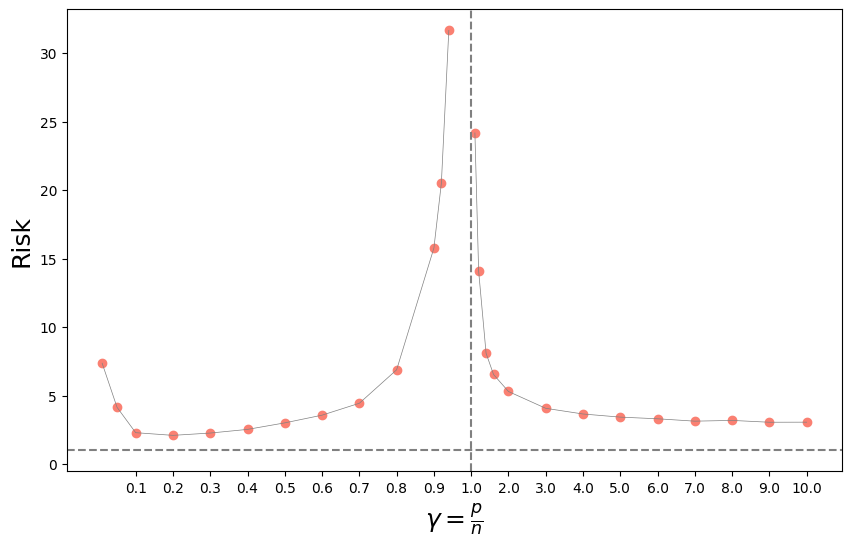

In [19]:
# Just evaluate the next line
plot_double_descent_risk(gammas, risk, sigma)

### Problem 3.2

Comment on the results. Explain why the risk plot does or does not make sense
in each regime: The underparameterized regime $\gamma < 1$, and the overparameterized
regime $\gamma > 1$. Is the curve "U-shaped" in the underparameterized regime? Why or why not?
What about in the overparameterized regime? You will be able to give better answers to these questions when you estimate the bias and variance below.


[Your markdown here]

In the underparameterized regime ($\gamma<1$), enlarging the model initially reduces risk because the added features include the informative directions of the true model. This leads to a rapid decrease in squared bias while the variance remains moderate, so the prediction error declines. As $\gamma$ approaches 1, the Gram matrix $X^\top X$ becomes poorly conditioned; the ordinary least squares estimator therefore becomes highly sensitive to observation noise and sampling fluctuations. The variance component grows sharply, and the risk correspondingly increases. The resulting shape is not a symmetric U; rather, it exhibits a pronounced valley followed by a steep ascent that is driven by variance inflation near the interpolation threshold.

At the interpolation point $(\gamma \approx 1$), the estimator is unstable because small singular values of $X$ amplify the noise. This instability manifests as a spike in test error, reflecting the explosion of the variance term in the bias–variance decomposition.

In the overparameterized regime ($\gamma>1$), the fitted model is obtained via the minimum-norm least-squares solution. Among all interpolants, this solution minimizes the $\ell_2$ norm of the coefficients, which functions as an implicit regularizer. As the number of features increases beyond the interpolation threshold, the additional random features are largely uncorrelated with the signal and acquire small weights under the minimum-norm criterion. The variance consequently decreases from its peak, while the squared bias remains small because the relevant signal features were already present. The risk therefore descends again, yielding the characteristic second descent rather than a U-shape.

Finally, the curve on the far right levels off above the irreducible noise level $\sigma^2$. With a finite sample size $n=200$, residual variance and limited approximation capacity prevent the risk from reaching $\sigma^2$ exactly. Increasing $n$ would push the right-hand tail closer to the noise floor. In summary: for $\gamma<1$ the risk decreases then rises due to worsening conditioning (not a symmetric U); near $\gamma=1$ it spikes; for $\gamma>1$ it decreases again due to implicit regularization by the minimum-norm solution.


### Problem 3.3

Now, modify the above code so that you can estimate both the squared bias and the
variance of the estimator. Before you do this, you may want to revisit the kernel smoothing demo from class, where we computed the squared bias, variance, and risk. You'll need the true function, which is provided in the variable `yf`.  You should not have to write a lot of code, but can compute the bias and variance after you store the predicted values on the test data for each trial.

Plot the results, by plotting both the squared bias, the variance, and the risk for the sequence of gammas. To do this you will have to modify the plotting function appropriately, but this again involves minimal changes. When you obtain your final plot, comment
on the shape of the bias and variance curves, as above for Problem 3.2.


In [ ]:
# Your code and markdown here.

In [16]:
trials = 100
n = 200
N_test = 1000

gammas = list(np.arange(.1, 1, .1)) + [.92, .94, 1, 1.1, 1.2, 1.4, 1.6] + list(np.arange(2, 11, 1))
gammas = [.01, .05] + gammas

risk = []
bias2_list = []
var_list = []

for gamma in gammas:
    p = int(n * gamma)

    if gamma == 1:
        risk.append(np.inf)
        bias2_list.append(np.inf)
        var_list.append(np.inf)
        continue

    W = (1/np.sqrt(d)) * np.random.randn(d, p)
    W[:, :min(p, p_star)] = W_star[:, :min(p, p_star)]

    all_idx = np.arange(X.shape[0])
    test_idx = np.random.choice(all_idx, size=N_test, replace=False)
    X_test = X[test_idx]
    y_test = yf[test_idx, 0]
    f_test = yf[test_idx, 1]

    H_test = np.tanh(X_test @ W)

    train_pool = np.setdiff1d(all_idx, test_idx, assume_unique=False)

    yhat_trials = []
    err = []

    for _ in range(trials):
        train_idx = np.random.choice(train_pool, size=n, replace=False)
        X_train = X[train_idx]
        y_train = yf[train_idx, 0]

        H_train = np.tanh(X_train @ W)

        beta_hat = OLS_or_minimum_norm(H_train, y_train)

        yhat_test = H_test @ beta_hat
        yhat_trials.append(yhat_test)
        err.append(np.mean((yhat_test - y_test)**2))

    yhat_trials = np.vstack(yhat_trials)


    risk_mean = float(np.mean(err))
    yhat_mean = yhat_trials.mean(axis=0)

    bias2 = float(np.mean((yhat_mean - f_test)**2))

    var = float(np.mean(yhat_trials.var(axis=0, ddof=1)))

    print('gamma=%.2f  p=%d  n=%d  risk=%.3f  bias^2=%.3f  var=%.3f '
          % (gamma, p, n, risk_mean, bias2, var))

    risk.append(risk_mean)
    bias2_list.append(bias2)
    var_list.append(var)


gamma=0.01  p=2  n=200  risk=7.262  bias^2=6.221  var=0.076 
gamma=0.05  p=10  n=200  risk=3.852  bias^2=2.775  var=0.192 
gamma=0.10  p=20  n=200  risk=2.363  bias^2=1.108  var=0.250 
gamma=0.20  p=40  n=200  risk=2.074  bias^2=0.667  var=0.457 
gamma=0.30  p=60  n=200  risk=2.128  bias^2=0.516  var=0.741 
gamma=0.40  p=80  n=200  risk=2.566  bias^2=0.447  var=1.061 
gamma=0.50  p=100  n=200  risk=2.873  bias^2=0.357  var=1.587 
gamma=0.60  p=120  n=200  risk=3.745  bias^2=0.244  var=2.440 
gamma=0.70  p=140  n=200  risk=4.433  bias^2=0.135  var=3.378 
gamma=0.80  p=160  n=200  risk=7.035  bias^2=0.095  var=5.974 
gamma=0.90  p=180  n=200  risk=15.271  bias^2=0.139  var=14.302 
gamma=0.92  p=184  n=200  risk=21.980  bias^2=0.245  var=20.860 
gamma=0.94  p=188  n=200  risk=30.679  bias^2=0.328  var=29.723 
gamma=1.10  p=220  n=200  risk=23.165  bias^2=0.277  var=22.207 
gamma=1.20  p=240  n=200  risk=13.240  bias^2=0.148  var=12.163 
gamma=1.40  p=280  n=200  risk=8.306  bias^2=0.116  

In [20]:
def plot_double_descent_all(gammas, risk, bias2, var, sigma):
    gammas = np.round(np.asarray(gammas, dtype=float), 2)
    risk   = np.asarray(risk, dtype=float)
    bias2  = np.asarray(bias2, dtype=float)
    var    = np.asarray(var, dtype=float)

    tick_pos = np.zeros(len(gammas))
    for i, g in enumerate(gammas):
        tick_pos[i] = g * 10 if g <= 1 else g + 9

    fig, ax = plt.subplots(figsize=(10, 6))

    idx1 = np.where(gammas == 1)[0]
    if len(idx1) > 0:
        ax.axvline(x=tick_pos[idx1[0]], linestyle='dashed', color='gray', linewidth=1)
    ax.axhline(y=sigma**2, linestyle='dashed', color='gray', linewidth=1)

    m_risk  = np.isfinite(risk)
    m_bias2 = np.isfinite(bias2)
    m_var   = np.isfinite(var)

    left  = gammas < 1
    right = gammas > 1

    def plot_piecewise(y, mask, label, marker, color):
        ax.scatter(tick_pos[mask], y[mask], marker=marker, label=label, color=color, zorder=3)
        mL = mask & left
        orderL = np.argsort(tick_pos[mL])
        ax.plot(tick_pos[mL][orderL], y[mL][orderL], linewidth=0.8, color=color)
        mR = mask & right
        orderR = np.argsort(tick_pos[mR])
        ax.plot(tick_pos[mR][orderR], y[mR][orderR], linewidth=0.8, color=color)

    plot_piecewise(risk,  m_risk,  'Risk (MSE)',   'o', 'tab:red')
    plot_piecewise(bias2, m_bias2, 'Squared Bias', 's', 'tab:blue')
    plot_piecewise(var,   m_var,   'Variance',     '^', 'tab:green')

    tickgam = [g for g in gammas if (g > .05 and g <= .9) or g >= 2 or g == 1]
    ticks   = [tick_pos[j] for j in range(len(tick_pos)) if gammas[j] in tickgam]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tickgam)

    ax.set_xlabel(r'$\gamma = \frac{p}{n}$', fontsize=14)
    ax.set_ylabel('MSE', fontsize=14)
    ax.set_title('Risk, Squared Bias, and Variance vs. Model Size (γ)', fontsize=15)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

    return fig, ax


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Risk, Squared Bias, and Variance vs. Model Size (γ)'}, xlabel='$\\gamma = \\frac{p}{n}$', ylabel='MSE'>)

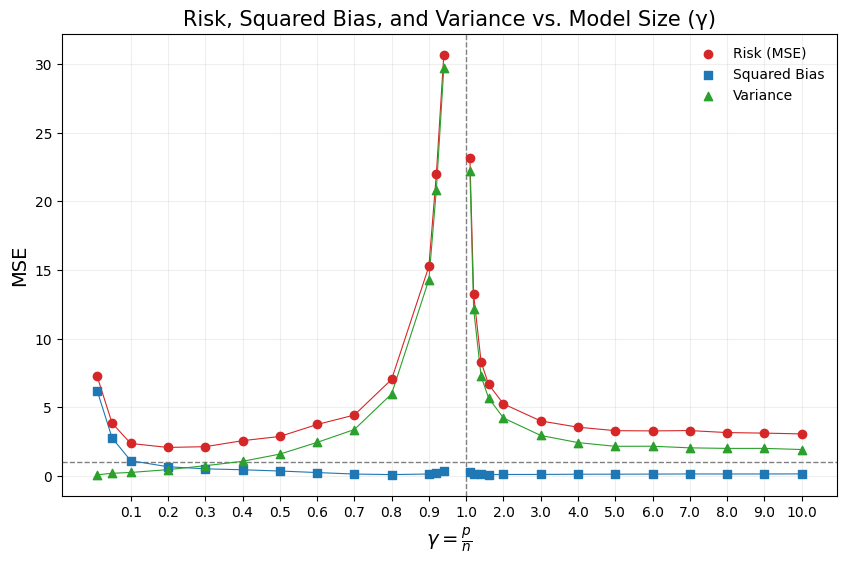

In [21]:
plot_double_descent_all(gammas, risk, bias2_list, var_list, sigma)

The squared bias typically decreases monotonically as $\gamma = p/n$ increases. In the underparameterized regime ($\gamma \ll 1$), the model class is too limited to approximate the teacher, so the expected predictor remains far from the ground truth and the squared bias is large. As $\gamma$ approaches $1$, representational capacity improves and the squared bias declines rapidly. In the overparameterized regime ($\gamma > 1$), once $p \ge p^*$, the model class contains the teacher’s features due to the alignment $W[:, :p^*] = W_*[:, :p^*]$, and the squared bias becomes small and often negligible.

The variance exhibits a markedly different behavior. It remains modest in the underparameterized regime, where the least-squares solution is unique and relatively stable. As $\gamma$ approaches the interpolation threshold $\gamma \approx 1$, the design matrix becomes ill-conditioned, which produces pronounced sensitivity of the fitted predictor to fluctuations in the training data; consequently, the variance attains its maximum. For $\gamma > 1$, when minimum-norm interpolation is employed, the variance decreases again as the implicit regularization of the minimum-norm solution stabilizes predictions despite the proliferation of parameters.

Combining these effects, the risk (expected test mean-squared error) decomposes into squared bias plus variance plus the irreducible noise $\sigma^2$. Accordingly, one observes the classical double-descent pattern: the risk is initially elevated due to bias for small $\gamma$, it peaks near $\gamma \approx 1$ due to variance inflation, and then it declines again for large $\gamma$ as variance recedes while bias remains minimal, approaching the noise floor $\sigma^2$.

### Problem 3.4

In class, we discussed the interpretation of the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. Geometrically, we can describe $ \hat{\beta}_{\text{mn}} $ as the orthogonal projection of the zero vector in $ \mathbb{R}^p $ onto the $ (p-1) $-dimensional hyperplane $ \{ \beta : X\beta = Y \} $.  

This can also be viewed as "ridgeless" regression. In ridge regression, we minimize the objective function
$$
\| Y - X\beta  \|_2^2 + \lambda \| \beta \|_2^2,
$$
which has the closed-form solution
$$
\hat{\beta}_{\lambda} = (X^T X + \lambda I)^{-1} X^T Y.
$$

In the overparameterized regime where $ p > n $, it can be shown that as $ \lambda \to 0 $, $ \hat{\beta}_{\lambda} $ converges to $ \hat{\beta}_{\text{mn}} $.

Your task is to show that as $ \lambda \to 0 $, the limit of the ridge regression estimator $ \hat{\beta}_{\lambda} $, in the overparameterized regime where $ \gamma > 1 $, is the minimum-norm estimator $ \hat{\beta}_{\text{mn}} $. You may want to use the Woodbury formula for this derivation.


_Hint_:
1. Applying the simplified version of Woodbury formula
$$
(I + UV^T)^{-1} = I - U(I + V^T U)^{-1} V^T.
$$
we can derive the identity:
$$
(X^T X + \lambda I_p)^{-1} X^T = X^T (X X^T + \lambda I_n)^{-1},
$$
2. You might consider using the Woodbury formula twice.



[Your markdown here]



We want to show that in the overparameterized regime $p>n$ (aspect ratio $\gamma>1$),
$$
\lim_{\lambda\to 0}\,\hat\beta_\lambda \;=\; \hat\beta_{\text{mn}},
$$
where
$$
\hat\beta_\lambda \;=\; (X^\top X+\lambda I_p)^{-1}X^\top Y.
$$

Using the Woodbury identity in the form
$$
(X^\top X+\lambda I_p)^{-1}X^\top \;=\; X^\top(XX^\top+\lambda I_n)^{-1},
$$
we can rewrite ridge as
$$
\hat\beta_\lambda \;=\; X^\top(XX^\top+\lambda I_n)^{-1}Y.
$$

Take an SVD $X=U\Sigma V^\top$ with singular values $\sigma_1\ge\cdots\ge\sigma_r>0$, $r=\mathrm{rank}(X)\le n$. Then
$$
XX^\top \;=\; U\,\mathrm{diag}(\sigma_1^2,\dots,\sigma_r^2,0,\dots,0)\,U^\top,
$$
so
$$
(XX^\top+\lambda I_n)^{-1}
\;=\;
U\,\mathrm{diag}\!\Big(\tfrac{1}{\sigma_1^2+\lambda},\dots,\tfrac{1}{\sigma_r^2+\lambda},\tfrac{1}{\lambda},\dots,\tfrac{1}{\lambda}\Big)U^\top.
$$
Hence
$$
\begin{aligned}
\hat\beta_\lambda
&= X^\top(XX^\top+\lambda I_n)^{-1}Y \\
&= V\Sigma^\top U^\top
\;U\,\mathrm{diag}\!\Big(\tfrac{1}{\sigma_1^2+\lambda},\dots,\tfrac{1}{\sigma_r^2+\lambda},\tfrac{1}{\lambda},\dots,\tfrac{1}{\lambda}\Big)U^\top Y \\
&= V\,\mathrm{diag}\!\Big(\tfrac{\sigma_1}{\sigma_1^2+\lambda},\dots,\tfrac{\sigma_r}{\sigma_r^2+\lambda},0,\dots,0\Big)\,U^\top Y.
\end{aligned}
$$
Taking $\lambda\to 0$,
$$
\tfrac{\sigma_i}{\sigma_i^2+\lambda}\;\longrightarrow\;\tfrac{1}{\sigma_i}\quad (i=1,\dots,r),
\qquad
0\;\longrightarrow\;0,
$$
and therefore
$$
\lim_{\lambda\to 0}\hat\beta_\lambda
\;=\;
V\,\mathrm{diag}\!\Big(\tfrac{1}{\sigma_1},\dots,\tfrac{1}{\sigma_r},0,\dots,0\Big)\,U^\top Y
\;=\;
V\Sigma^+U^\top Y
\;=\;
X^T(XX^T)^{-1}Y
\;=\;
\hat\beta_{\text{mn}}.
$$
